# PCA Laboratory: Principal Component Analysis From Scratch

**Objective.** Implement PCA manually (via covariance-matrix eigendecomposition), validate against `sklearn`, and learn to interpret every output (explained variance, loadings, scores).

**Dataset.** Synthetic retail-customer dataset with a known latent factor structure, so recovered components have a verifiable ground truth.

## 1. Concept

PCA finds orthogonal directions (principal components, PCs) that maximize variance in the data. Formally, given standardized data matrix $X \in \mathbb{R}^{n\times p}$:

1. Compute covariance matrix: $C = \frac{1}{n-1}X^TX$
2. Eigendecompose: $C v_i = \lambda_i v_i$
3. Sort eigenvectors $v_i$ by eigenvalue $\lambda_i$ descending → PCs ranked by variance explained
4. Project: $\text{Scores} = X V_k$ ($V_k$ = top-$k$ eigenvectors)

**Key quantities:**
- **Eigenvalue** $\lambda_i$: variance captured by PC$_i$
- **Explained variance ratio**: $\lambda_i / \sum_j \lambda_j$
- **Loadings**: entries of $v_i$ — contribution/weight of each original variable to PC$_i$
- **Scores**: coordinates of observations in PC space


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.rcParams["figure.figsize"] = (6, 4)


## 2. Practical Dataset

Two hidden factors drive six observed customer variables:
- **Factor 1 ("affluence")** → income, avg. purchase value, credit score
- **Factor 2 ("engagement")** → spending score, number of purchases, age (inversely)

This construction guarantees the first two PCs should recover most variance — useful to check correctness of the implementation.


In [2]:
n = 200

factor1 = np.random.normal(0, 1, n)   # affluence
factor2 = np.random.normal(0, 1, n)   # engagement

df = pd.DataFrame({
    "Annual_Income_k":        50 + 15*factor1 + np.random.normal(0, 3, n),
    "Avg_Purchase_Value":     40 + 12*factor1 + np.random.normal(0, 4, n),
    "Credit_Score":           650 + 40*factor1 + np.random.normal(0, 10, n),
    "Spending_Score":         50 + 18*factor2 + np.random.normal(0, 4, n),
    "Num_Purchases_Year":     20 + 6*factor2 + np.random.normal(0, 2, n),
    "Age":                    45 - 8*factor2 + np.random.normal(0, 5, n),
})

df.head()


,Annual_Income_k,Avg_Purchase_Value,Credit_Score,Spending_Score,Num_Purchases_Year,Age
0,52.667429,48.988524,679.251404,62.037594,22.397173,36.903146
1,46.127910,34.652167,639.308981,63.792656,22.505896,43.196988
2,59.731059,51.250686,676.868749,69.733444,26.742902,42.264111
3,72.986390,63.698910,706.298441,66.380690,27.409408,40.164350
4,45.137503,38.843899,636.288903,27.994845,11.831704,61.001593


In [3]:
df.describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
Annual_Income_k,49.131470,13.883030,15.638727,94.233800
Avg_Purchase_Value,39.546615,12.141110,2.933012,75.124718
Credit_Score,649.651676,38.157466,544.878926,766.410913
Spending_Score,52.080159,18.080670,-3.747749,117.208226
Num_Purchases_Year,20.525958,6.218158,1.629908,46.615542
Age,44.726207,9.095387,12.923983,69.885022


**Note.** Variables are on different scales (e.g., `Credit_Score` ~650 vs `Age` ~45) and different units. PCA is scale-sensitive (it maximizes variance, and variance depends on units), so standardization ($z = (x-\mu)/\sigma$) is mandatory before applying it.


In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(df)
X = pd.DataFrame(X, columns=df.columns)
X.describe().T[["mean", "std"]].round(2)   # mean~0, std=1 confirms standardization


,mean,std
Annual_Income_k,-0.0,1.0
Avg_Purchase_Value,0.0,1.0
Credit_Score,0.0,1.0
Spending_Score,-0.0,1.0
Num_Purchases_Year,-0.0,1.0
Age,0.0,1.0


## 3. Correlation Structure (why PCA is useful here)

Correlated variables carry redundant information. PCA compresses this redundancy into fewer uncorrelated components.


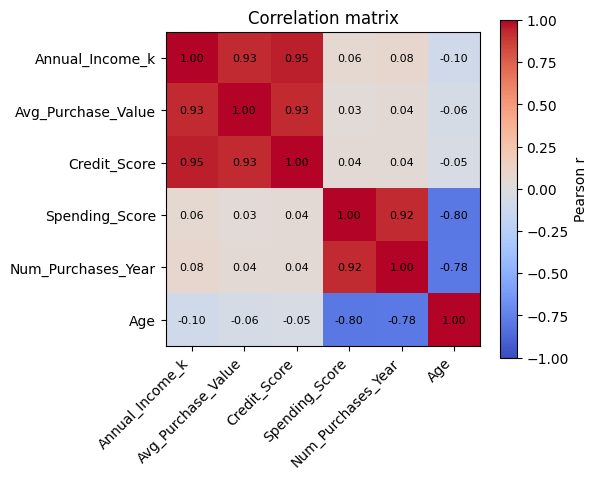

In [5]:
corr = X.corr()
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, label="Pearson r")
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()


**Reading this plot.** Two clear blocks should appear: `{Annual_Income_k, Avg_Purchase_Value, Credit_Score}` correlate strongly with each other (affluence factor), and `{Spending_Score, Num_Purchases_Year, Age}` correlate with each other (engagement factor, `Age` negatively). Strong block correlation ⇒ dimensionality reduction is justified.

## 4. PCA From Scratch (manual eigendecomposition)


In [6]:
Xm = X.values  # standardized data as numpy array

# Step 1: covariance matrix (n-1 denominator = sample covariance)
cov_matrix = np.cov(Xm, rowvar=False)

# Step 2: eigendecomposition (covariance matrix is symmetric -> eigh is stable/exact)
eigvals, eigvecs = np.linalg.eigh(cov_matrix)

# Step 3: sort descending (eigh returns ascending order)
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

print("Eigenvalues:\n", eigvals.round(3))


Eigenvalues:
 [2.984 2.583 0.256 0.081 0.078 0.048]


In [7]:
explained_var_ratio = eigvals / eigvals.sum()
cum_var = np.cumsum(explained_var_ratio)

summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(eigvals))],
    "Eigenvalue": eigvals.round(3),
    "Explained_Var_%": (explained_var_ratio*100).round(2),
    "Cumulative_%": (cum_var*100).round(2)
})
summary


,PC,Eigenvalue,Explained_Var_%,Cumulative_%
0,PC1,2.984,49.48,49.48
1,PC2,2.583,42.83,92.30
2,PC3,0.256,4.25,96.56
3,PC4,0.081,1.35,97.90
4,PC5,0.078,1.30,99.20
5,PC6,0.048,0.80,100.00


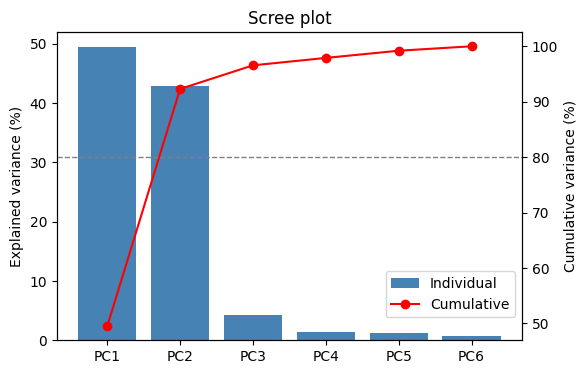

In [8]:
fig, ax1 = plt.subplots()
ax1.bar(summary["PC"], summary["Explained_Var_%"], color="steelblue", label="Individual")
ax1.set_ylabel("Explained variance (%)")
ax2 = ax1.twinx()
ax2.plot(summary["PC"], summary["Cumulative_%"], color="red", marker="o", label="Cumulative")
ax2.set_ylabel("Cumulative variance (%)")
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
plt.title("Scree plot")
fig.legend(loc="lower right", bbox_to_anchor=(0.9,0.15))
plt.show()


**Reading the scree plot.** Bars = variance captured by each individual PC; red line = cumulative variance. Retain enough PCs to cross a chosen threshold (commonly 70–90%) or apply the "elbow rule" (keep PCs before the curve flattens). Given the two-factor construction, expect PC1+PC2 to already cross ~80%.

## 5. Project Data Onto Principal Components (Scores)


In [9]:
k = 2  # number of components retained
V_k = eigvecs[:, :k]
scores = Xm @ V_k   # projection: (n x p) @ (p x k) = (n x k)

scores_df = pd.DataFrame(scores, columns=[f"PC{i+1}" for i in range(k)])
scores_df.head()


,PC1,PC2
0,-1.395685,-0.317528
1,0.116788,-0.835902
2,-1.874285,-0.435836
3,-3.297543,0.290073
4,1.656824,2.052951


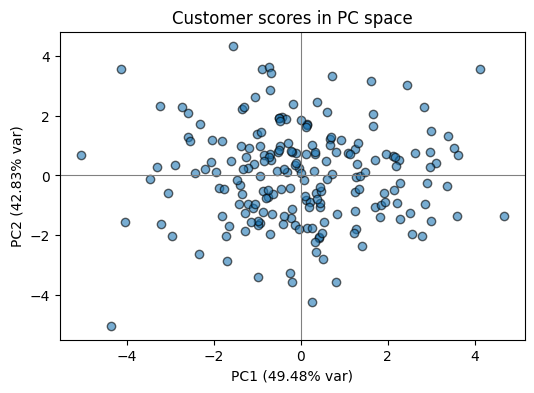

In [10]:
plt.scatter(scores_df["PC1"], scores_df["PC2"], alpha=0.6, edgecolor="k")
plt.xlabel(f"PC1 ({summary.loc[0,'Explained_Var_%']}% var)")
plt.ylabel(f"PC2 ({summary.loc[1,'Explained_Var_%']}% var)")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("Customer scores in PC space")
plt.show()


**Reading the scores plot.** Each point = one customer, positioned by its coordinates on PC1/PC2. Points far from the origin along PC1 are extreme in the "affluence" direction; along PC2, extreme in "engagement". Clusters or gradients here reveal customer segments without needing all 6 original variables.

## 6. Loadings (What Each PC Represents)


In [11]:
loadings = pd.DataFrame(V_k, index=df.columns, columns=[f"PC{i+1}" for i in range(k)])
loadings.round(3)


,PC1,PC2
Annual_Income_k,-0.508,0.275
Avg_Purchase_Value,-0.494,0.294
Credit_Score,-0.497,0.297
Spending_Score,-0.288,-0.515
Num_Purchases_Year,-0.292,-0.509
Age,0.286,0.476


**Reading loadings.** Each column is a unit-length eigenvector. Large absolute values indicate the original variable strongly drives that PC; sign indicates direction. Expect `Annual_Income_k`, `Avg_Purchase_Value`, `Credit_Score` to load heavily on PC1, and `Spending_Score`, `Num_Purchases_Year`, `Age` (opposite sign) on PC2 — recovering the two simulated factors.

## 7. Biplot (Scores + Loadings Together)


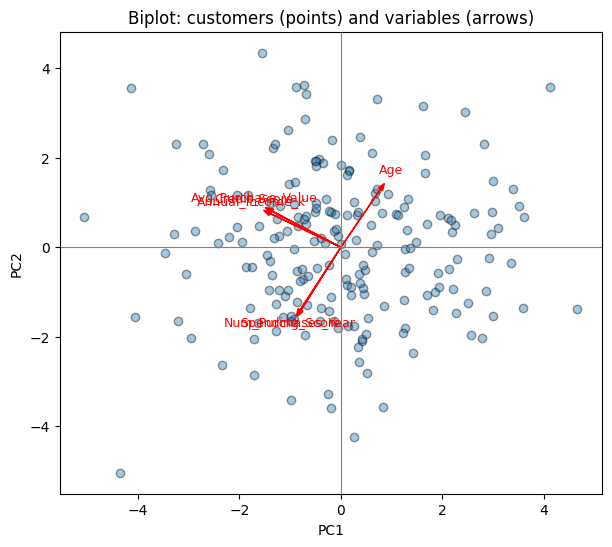

In [12]:
scale = 3  # arrow scale factor purely for visibility
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(scores_df["PC1"], scores_df["PC2"], alpha=0.4, edgecolor="k", label="Customers")

for var in loadings.index:
    ax.arrow(0, 0, loadings.loc[var,"PC1"]*scale, loadings.loc[var,"PC2"]*scale,
              color="red", head_width=0.1, length_includes_head=True)
    ax.text(loadings.loc[var,"PC1"]*scale*1.15, loadings.loc[var,"PC2"]*scale*1.15,
             var, color="red", fontsize=9, ha="center")

ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Biplot: customers (points) and variables (arrows)")
plt.show()


**Reading the biplot.** Arrow direction = variable's loading vector; arrow length = strength of contribution; angle between arrows ≈ correlation between variables (small angle → correlated, ~90° → uncorrelated, ~180° → anti-correlated). Points near an arrow's direction score high on that variable.

## 8. Validation Against `sklearn`


In [13]:
pca = PCA(n_components=k)
sk_scores = pca.fit_transform(Xm)

print("Explained variance ratio (sklearn):", pca.explained_variance_ratio_.round(4))
print("Explained variance ratio (manual): ", explained_var_ratio[:k].round(4))

# sign of eigenvectors is arbitrary -> compare absolute correlation between manual and sklearn scores
for i in range(k):
    r = np.corrcoef(sk_scores[:,i], scores[:,i])[0,1]
    print(f"PC{i+1}: |corr(manual, sklearn)| = {abs(r):.4f}  (expect ~1.0000)")


Explained variance ratio (sklearn): [0.4948 0.4283]
Explained variance ratio (manual):  [0.4948 0.4283]
PC1: |corr(manual, sklearn)| = 1.0000  (expect ~1.0000)
PC2: |corr(manual, sklearn)| = 1.0000  (expect ~1.0000)


**Note on sign ambiguity.** Eigenvectors are only defined up to a sign flip ($v$ and $-v$ both solve $Cv=\lambda v$); `sklearn` may return the mirrored version. This is why validation compares absolute correlation, not raw equality — a value near 1.0000 confirms the manual implementation matches `sklearn` exactly, up to that sign convention.

## 9. Summary — How to Read PCA Output

| Output | Meaning | What to check |
|---|---|---|
| Eigenvalues | Variance per PC | Larger = more informative PC |
| Explained variance ratio | % of total variance per PC | Sum of retained PCs should reach chosen threshold (e.g., ≥80%) |
| Scree plot | Visual variance drop-off | Elbow point suggests how many PCs to keep |
| Loadings | Weight of each original variable on a PC | High \|loading\| ⇒ variable defines that PC's meaning |
| Scores | Observation coordinates in PC space | Used for plotting, clustering, or as reduced-dimension features |
| Biplot | Scores + loadings overlay | Arrow angles reveal variable correlations; point-arrow proximity reveals which variables drive an observation's position |

**Exercises to extend this lab:**
1. Re-run with 3 latent factors and 9 variables — check if the scree plot correctly suggests 3 PCs.
2. Add an outlier customer and observe its effect on PC1 loadings.
3. Skip standardization and compare loadings/results — verify that unscaled variables with larger variance dominate PC1.
